In [66]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
%matplotlib widget
plt.rcParams['font.sans-serif'] = 'Times New Roman' #Times New Roman
plt.rcParams.update({'font.size': 12}) 
import scipy.fft
from scipy import signal
from scipy.signal import welch, csd, coherence, find_peaks
import os
import time

plt.rcParams['font.sans-serif'] = 'Times New Roman'
plt.rcParams['figure.figsize'] = (5, 4.5)
plt.rcParams['figure.dpi'] = 80
plt.rcParams.update({'font.size': 12}) 

In [67]:
data = [archivo for archivo in os.listdir('./Registros/') if archivo.endswith(".lvm")]
for i in range(len(data)):
    print('[{}]'.format(i),'-->', data[i])

[0] --> 3NBR_2NBF_27F.lvm
[1] --> RDT Piso1-1.lvm
[2] --> RDT Piso1-2.lvm
[3] --> RDT Piso1-3.lvm
[4] --> RDT Piso2-1.lvm
[5] --> RDT Piso2-2.lvm
[6] --> RDT Piso2-3.lvm
[7] --> RDT Piso3-1.lvm
[8] --> RDT Piso3-2.lvm
[9] --> RDT Piso3-3.lvm
[10] --> RDT Piso3-4.lvm
[11] --> RDT Piso3-5.lvm
[12] --> RDT Piso3-6.lvm
[13] --> RDT Vibracion libre 1-1.lvm
[14] --> RDT Vibracion libre 1-2.lvm
[15] --> RDT Vibracion libre 1-3.lvm
[16] --> RDT Vibracion libre 1-4.lvm
[17] --> RDT Vibracion libre 1-5.lvm


In [68]:
enss = data[1]
print(f'Registro escogido: {enss}')

Registro escogido: RDT Piso1-1.lvm


In [69]:
df = pd.read_table('./Registros/{}'.format(enss), skiprows=22, decimal=",")
df.columns = ['Tiempo [s]', 'A1', 'A2', 'A3', 'Hammer', 'Comment']
#df.columns = ['Tiempo [s]', 'A1', 'A2', 'A3', 'Hammer', 'Comment']
#df.drop(['Comment'], axis=1, inplace=True)
#df = df.drop(columns=['Comment'])
display(df)

,Tiempo [s],A1,A2,A3,Hammer,Comment
0,0.000000,0.000179,0.000238,0.000227,0.000167,NaN
1,0.000488,0.000189,0.000314,0.000241,0.000106,NaN
2,0.000977,0.000146,0.000283,0.000228,0.000171,NaN
3,0.001465,0.000131,0.000301,0.000255,0.000177,NaN
4,0.001953,0.000176,0.000285,0.000218,0.000162,NaN
...,...,...,...,...,...,...
40955,19.997559,0.000154,0.000279,0.000255,0.000154,NaN
40956,19.998047,0.000138,0.000253,0.000236,0.000158,NaN
40957,19.998535,0.000157,0.000287,0.000252,0.000139,NaN
40958,19.999023,0.000172,0.000255,0.000243,0.000227,NaN


In [70]:
import pandas as pd
import numpy as np

# Si ya tienes cargado el DataFrame como df, partimos desde ahí.
# Columnas esperadas:
# T, X1L, Y1L, Z1L, X2L, Y2L, Z2L, X3L, Y3L, Z3L, X4L, Y4L, Z4L

v = df.copy()

# Convertir columna T a fecha/hora
#df["T_datetime"] = pd.to_datetime(df["T"], format="%d-%b-%Y %H:%M:%S", errors="coerce")

# Revisar si hubo errores de conversión
#print("Fechas no convertidas:", df["T_datetime"].isna().sum())

# Duración según el timestamp original
t_ini = df["Tiempo [s]"].iloc[0]
t_fin = df["Tiempo [s]"].iloc[-1]

# Estimar frecuencia de muestreo
fs_est = (len(df) - 1) / t_fin
print("Frecuencia de muestreo estimada [Hz]:", fs_est)

Frecuencia de muestreo estimada [Hz]: 2047.9999711992973


In [71]:
fs = round(fs_est)   # debería ser 150 Hz aproximadamente
dt = 1 / fs

df["t_s"] = np.arange(len(df)) * dt

print("fs usada [Hz]:", fs)
print("dt [s]:", dt)

fs usada [Hz]: 2048
dt [s]: 0.00048828125


In [72]:
canales = [
    "A1", "A2", "A3",
]

# Revisar datos faltantes
# print("Datos faltantes por canal:")
# print(df[canales].isna().sum())

# Estadística básica
resumen = df[canales].describe().T
resumen["rms"] = np.sqrt(np.mean(df[canales]**2, axis=0))
resumen["media_abs"] = df[canales].mean().abs()
resumen["max_abs"] = df[canales].abs().max()

resumen

,count,mean,std,min,25%,50%,75%,max,rms,media_abs,max_abs
A1,40960.0,0.000163,0.003128,-0.191659,0.000114,0.000162,0.000212,0.172116,0.003132,0.000163,0.191659
A2,40960.0,0.000280,0.008195,-0.339481,0.000250,0.000278,0.000312,1.150448,0.008200,0.000280,1.150448
A3,40960.0,0.000250,0.002345,-0.073771,0.000188,0.000250,0.000309,0.084687,0.002359,0.000250,0.084687


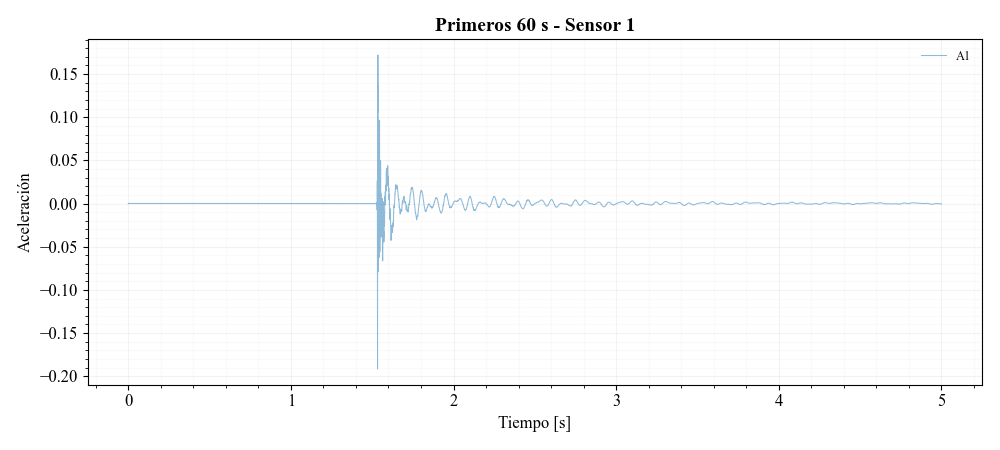

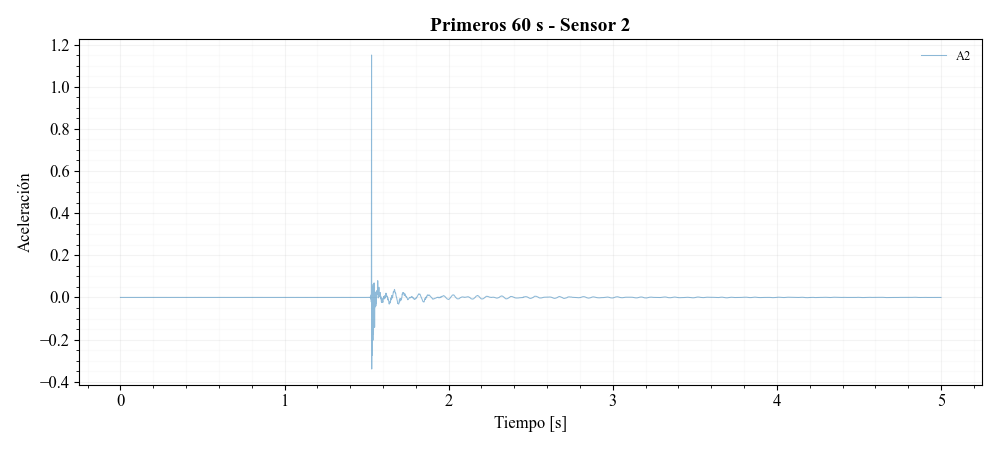

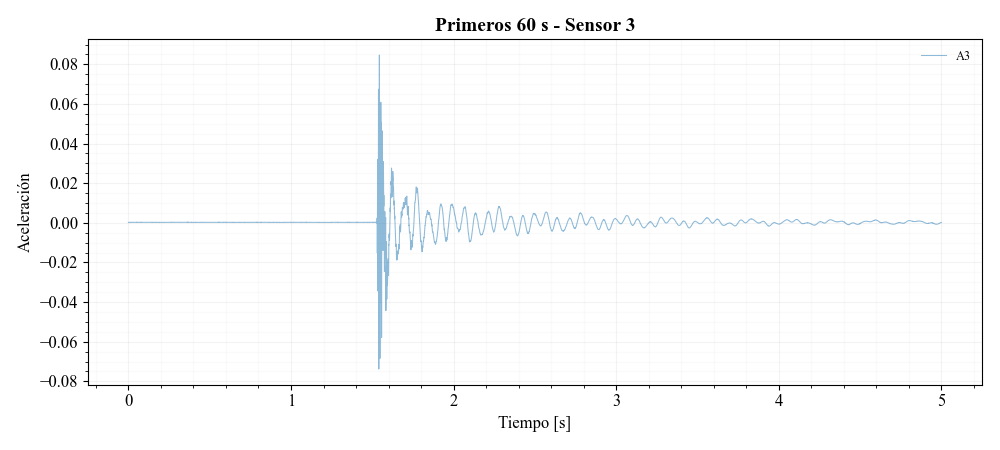

In [73]:
import matplotlib.pyplot as plt

t = df["t_s"].values
tmax = 5
idx = t <= tmax

for sensor in [1, 2, 3]:
    plt.figure(figsize=(10, 4.5), dpi = 100)
    for eje in ["A"]:
        col = f"{eje}{sensor}"
        plt.plot(t[idx], df.loc[idx, col], '-', alpha=0.5, linewidth=0.75, label=col)
    
    plt.grid(which="major", alpha=0.15)
    plt.minorticks_on()
    plt.grid(which="minor", alpha=0.05)
    plt.xlabel("Tiempo [s]", fontsize=12)
    plt.ylabel("Aceleración", fontsize=12)
    plt.title(f"Primeros 60 s - Sensor {sensor}", fontsize=14, fontweight='bold')
    plt.legend(loc=1, fontsize=9, ncol=1, frameon=False)
    plt.tight_layout()
    plt.show()

In [74]:
from scipy.signal import detrend

df_proc = df.copy()
for col in canales:
    df_proc[col] = detrend(df_proc[col].values, type="linear")

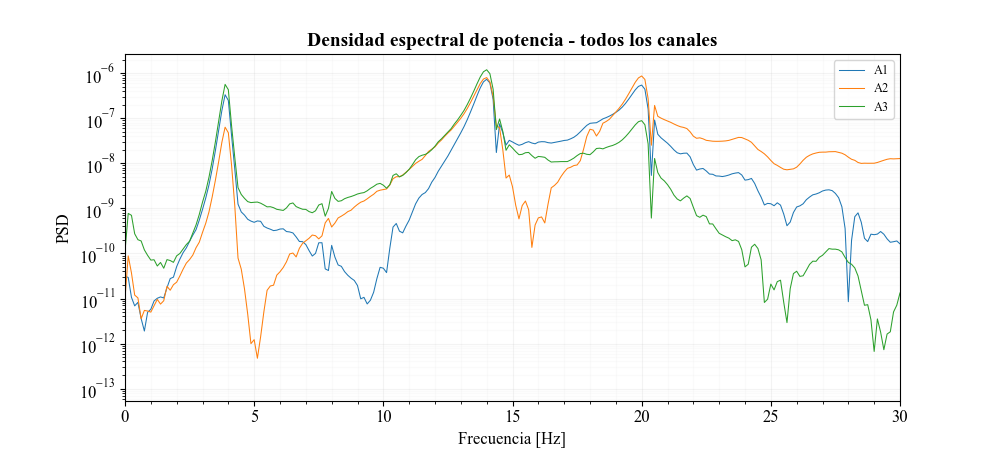

In [75]:
from scipy.signal import welch

# Para 20 minutos de datos, podemos usar ventanas largas.
# nperseg = 8192 da resolución aprox fs/nperseg = 0.018 Hz
nperseg = 16384
noverlap = nperseg // 2

psd = {}

for col in canales:
    f, Pxx = welch(
        df_proc[col].values,
        fs=fs,
        window="hann",
        nperseg=nperseg,
        noverlap=noverlap,
        detrend="constant",
        scaling="density"
    )
    psd[col] = Pxx

plt.figure(figsize=(10, 4.5), dpi = 100)
for col in canales:
    plt.semilogy(f, psd[col], alpha=1, linewidth=0.75, label=col)

plt.grid(which="major", alpha=0.15)
plt.minorticks_on()
plt.grid(which="minor", alpha=0.05)

plt.xlim(0, 30)
plt.xlabel("Frecuencia [Hz]", fontsize=12)
plt.ylabel("PSD", fontsize=12)
plt.title("Densidad espectral de potencia - todos los canales", fontsize=14, fontweight='bold')
plt.legend(loc=1, fontsize=9, ncol=1, frameon=True)
plt.show()

In [76]:
print("Duración:", df["t_s"].iloc[-1], "s")
print("fs:", fs, "Hz")
print("Nyquist:", fs/2, "Hz")
print("Resolución Welch aproximada:", fs/nperseg, "Hz")

Duración: 19.99951171875 s
fs: 2048 Hz
Nyquist: 1024.0 Hz
Resolución Welch aproximada: 0.125 Hz


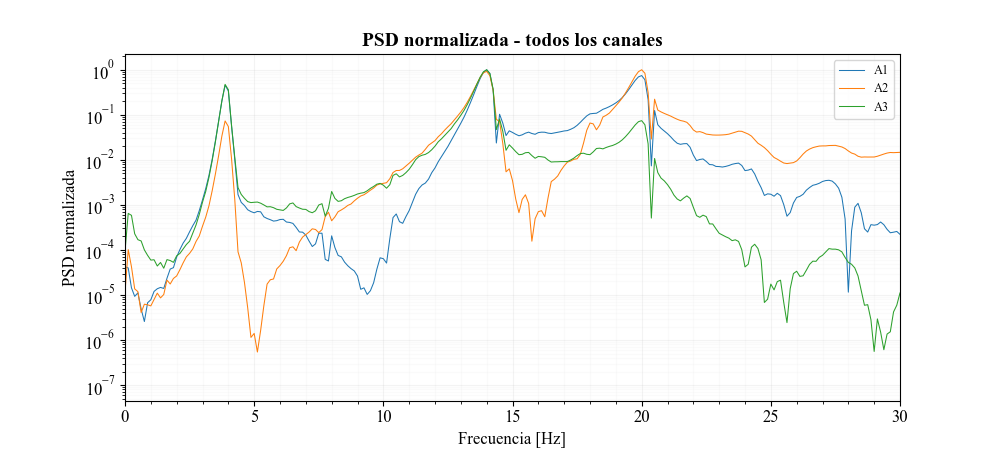

In [77]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch, detrend

df_proc = df.copy()

# Quitar media y tendencia
for col in canales:
    df_proc[col] = detrend(df_proc[col].values, type="linear")

plt.figure(figsize=(10, 4.5), dpi = 100)

for col in canales:
    f, Pxx = welch(
        df_proc[col].values,
        fs=fs,
        window="hann",
        nperseg=nperseg,
        noverlap=noverlap,
        detrend="constant",
        scaling="density"
    )
    
    # Normalización por máximo de cada canal
    Pxx_norm = Pxx / np.max(Pxx)
    
    plt.semilogy(f, Pxx_norm, alpha=1, linewidth=0.75, label=col)

plt.xlim(0, 30)
plt.xlabel("Frecuencia [Hz]", fontsize=12)
plt.ylabel("PSD normalizada", fontsize=12)
plt.title("PSD normalizada - todos los canales", fontsize=14, fontweight='bold')
plt.grid(which="major", alpha=0.15)
plt.minorticks_on()
plt.grid(which="minor", alpha=0.05)
plt.legend(loc=1, fontsize=9, ncol=1, frameon=True)
plt.show()

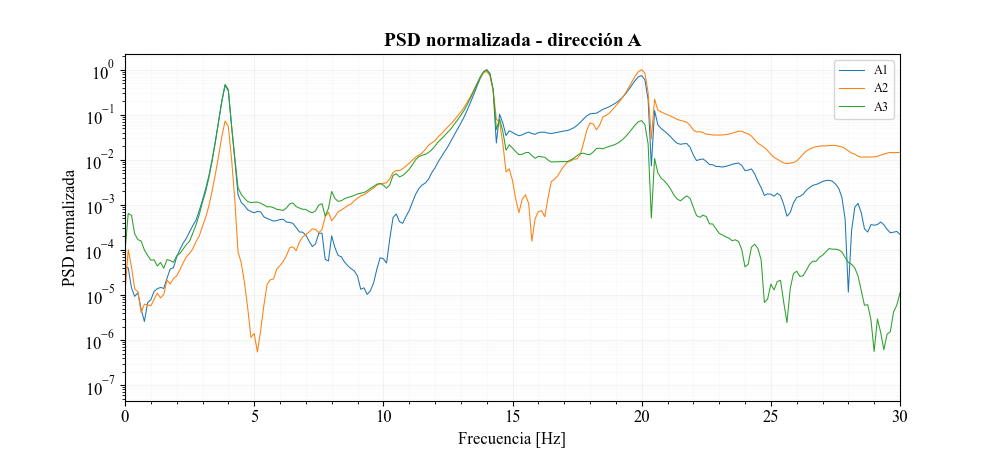

In [78]:
for eje in ["A"]:
    plt.figure(figsize=(10, 4.5), dpi = 100)
    
    for sensor in [1, 2, 3]:
        col = f"{eje}{sensor}"
        
        f, Pxx = welch(
            df_proc[col].values,
            fs=fs,
            window="hann",
            nperseg=nperseg,
            noverlap=noverlap,
            detrend="constant",
            scaling="density"
        )
        
        Pxx_norm = Pxx / np.max(Pxx)
        plt.semilogy(f, Pxx_norm, alpha=1, linewidth=0.75, label=col)
    
    plt.xlim(0, 30)
    plt.xlabel("Frecuencia [Hz]", fontsize=12)
    plt.ylabel("PSD normalizada", fontsize=12)
    plt.title(f"PSD normalizada - dirección {eje}", fontsize=14, fontweight='bold')
    plt.grid(which="major", alpha=0.15)
    plt.minorticks_on()
    plt.grid(which="minor", alpha=0.05)
    plt.legend(loc=1, fontsize=9, ncol=1, frameon=True)
    plt.show()

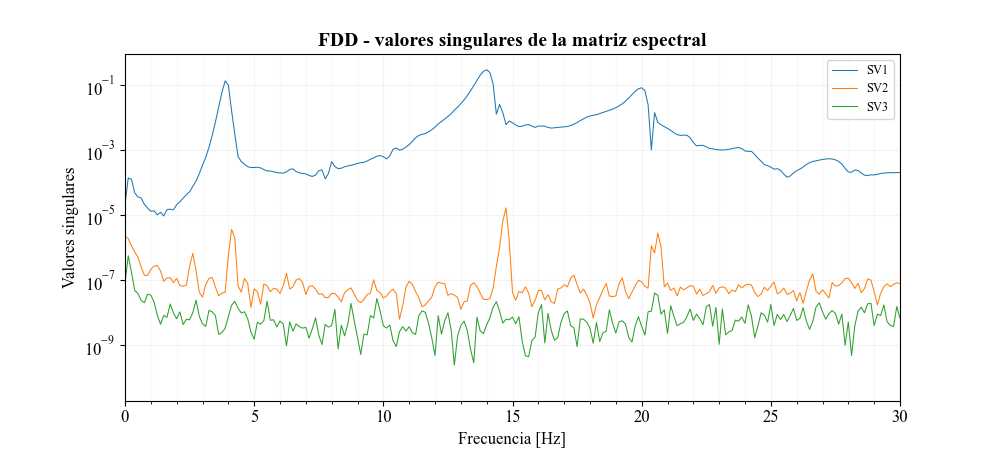

In [79]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import csd, detrend

# Matriz de datos
Y = df_proc[canales].values

# Normalizar cada canal por su desviación estándar
# Esto evita que un canal con mucha amplitud domine todo el FDD
Y_norm = (Y - np.mean(Y, axis=0)) / np.std(Y, axis=0)

nch = Y_norm.shape[1]

# Calcular matriz espectral para cada frecuencia
Gyy = None

for i in range(nch):
    for j in range(nch):
        f, Pij = csd(
            Y_norm[:, i],
            Y_norm[:, j],
            fs=fs,
            window="hann",
            nperseg=nperseg,
            noverlap=noverlap,
            detrend="constant",
            scaling="density"
        )
        
        if Gyy is None:
            nf = len(f)
            Gyy = np.zeros((nf, nch, nch), dtype=complex)
        
        Gyy[:, i, j] = Pij

# SVD frecuencia por frecuencia
singular_values = np.zeros((nf, nch))

for k in range(nf):
    U, S, Vh = np.linalg.svd(Gyy[k, :, :])
    singular_values[k, :] = S

# Graficar primeros valores singulares
plt.figure(figsize=(10, 4.5), dpi = 100)

for i in range(3):
    plt.semilogy(f, singular_values[:, i], alpha=1, linewidth=0.75, label=f"SV{i+1}")

plt.xlim(0, 30)
plt.xlabel("Frecuencia [Hz]", fontsize=12)
plt.ylabel("Valores singulares", fontsize=12)
plt.title("FDD - valores singulares de la matriz espectral", fontsize=14, fontweight='bold')
plt.grid(which="major", alpha=0.15)
plt.minorticks_on()
plt.grid(which="minor", alpha=0.05)
plt.legend(loc=1, fontsize=9, ncol=1, frameon=True)
plt.show()

In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# Guardar valores y vectores singulares
singular_values = np.zeros((nf, nch))
singular_vectors = np.zeros((nf, nch), dtype=complex)

for k in range(nf):
    U, S, Vh = np.linalg.svd(Gyy[k, :, :])
    singular_values[k, :] = S
    singular_vectors[k, :] = U[:, 0]   # primera forma singular

# Trabajamos con SV1
SV1 = singular_values[:, 0]

# Buscar peaks entre 0.5 y 30 Hz
mask = (f >= 0.5) & (f <= 30)

# Puedes ajustar prominence según tu gráfico
peaks, props = find_peaks(
    SV1[mask],
    prominence=0.03,
    distance=10
)

f_mask = f[mask]
SV1_mask = SV1[mask]

freq_peaks = f_mask[peaks]
amp_peaks = SV1_mask[peaks]

df_peaks = pd.DataFrame({
    "frecuencia_Hz": freq_peaks,
    "SV1": amp_peaks,
    "prominence": props["prominences"]
})

df_peaks = df_peaks.sort_values("SV1", ascending=False)

df_peaks

,frecuencia_Hz,SV1,prominence
1,14.000,0.304559,0.304409
0,3.875,0.137907,0.137773
2,20.000,0.084914,0.080038


In [81]:
def extraer_forma_fdd(freq_objetivo, f, singular_vectors, canales):
    """
    Extrae la primera forma singular cercana a una frecuencia objetivo.
    """
    idx = np.argmin(np.abs(f - freq_objetivo))
    phi = singular_vectors[idx, :]
    
    # Normalizar por máximo absoluto
    phi = phi / np.max(np.abs(phi))
    
    df_phi = pd.DataFrame({
        "canal": canales,
        "parte_real": np.real(phi),
        "parte_imag": np.imag(phi),
        "magnitud": np.abs(phi),
        "fase_deg": np.angle(phi, deg=True)
    })
    
    return f[idx], df_phi

# Ejemplo para el peak cercano a 11.1 Hz
freq_real, forma_11 = extraer_forma_fdd(11.1, f, singular_vectors, canales)

print("Frecuencia extraída:", freq_real, "Hz")
forma_11

Frecuencia extraída: 11.125 Hz


,canal,parte_real,parte_imag,magnitud,fase_deg
0,A1,-0.224351,8.311806e-18,0.224351,180.000000
1,A2,-0.274030,1.419805e-02,0.274397,177.034037
2,A3,0.992095,-1.254876e-01,1.000000,-7.208913


In [82]:
def graficar_forma_por_sensor(df_phi, freq):
    sensores = [1, 2, 3]
    ejes = ["X"]
    
    valores = {eje: [] for eje in ejes}
    
    for sensor in sensores:
        for eje in ejes:
            canal = f"{eje}{sensor}L"
            valor = df_phi.loc[df_phi["canal"] == canal, "parte_real"].values[0]
            valores[eje].append(valor)
    
    x = np.arange(len(sensores))
    width = 0.25
    
    plt.figure(figsize=(10, 4.5), dpi = 100)
    plt.bar(x - width, valores["X"], width, label="X")
    plt.bar(x,         valores["Y"], width, label="Y")
    plt.bar(x + width, valores["Z"], width, label="Z")
    
    plt.xticks(x, [f"S{n}" for n in sensores])
    plt.axhline(0, color="black", linewidth=0.8)
    plt.xlabel("Sensor", fontsize=12)
    plt.ylabel("Forma modal relativa", fontsize=12)
    plt.title(f"Forma FDD aproximada - {freq:.3f} Hz", fontsize=14, fontweight='bold')
    plt.grid(which="major", alpha=0.15)
    plt.minorticks_on()
    plt.grid(which="minor", alpha=0.05)
    plt.legend(loc=1, fontsize=9, ncol=1, frameon=True)
    plt.show()

graficar_forma_por_sensor(forma_11, freq_real)

IndexError: index 0 is out of bounds for axis 0 with size 0

In [ ]:
import pandas as pd
import numpy as np

# -----------------------------
# CONFIGURACIÓN
# -----------------------------
archivo_entrada = "./DATA_CorreaOverland/20260203_1230_ARTEMIS.txt"
archivo_salida = "20260203_1230_ARTEMIS_con_ts.txt"

fs = 150  # Hz

canales = [
    "X1L", "Y1L", "Z1L",
    "X2L", "Y2L", "Z2L",
    "X3L", "Y3L", "Z3L",
    "X4L", "Y4L", "Z4L"
]

# -----------------------------
# LECTURA DEL ARCHIVO ORIGINAL
# -----------------------------
# El archivo tiene:
# T  X1L Y1L ...
# pero en las filas, T aparece como dos campos:
# 03-Feb-2026 12:20:00
# Por eso leemos fecha y hora por separado.

df = pd.read_csv(
    archivo_entrada,
    sep=r"\s+",
    skiprows=1,
    names=["fecha", "hora"] + canales,
    decimal=",",
    engine="python"
)

# -----------------------------
# CREAR VECTOR DE TIEMPO EN SEGUNDOS
# -----------------------------
df.insert(0, "t_s", np.arange(len(df)) / fs)

# Eliminar fecha y hora original
df_out = df[["t_s"] + canales]

# -----------------------------
# EXPORTAR EN FORMATO SIMILAR A ARTEMIS
# -----------------------------
# sep="\t"          -> columnas separadas por tabulación
# decimal=","       -> mantiene coma decimal
# index=False       -> no exporta índice de pandas

df_out.to_csv(
    archivo_salida,
    sep="\t",
    decimal=",",
    index=False
)

print(f"Archivo generado: {archivo_salida}")
print(df_out.head())
print(df_out.tail())

Archivo generado: 20260203_1230_ARTEMIS_con_ts.txt
        t_s       X1L       Y1L       Z1L       X2L       Y2L       Z2L  \
0  0.000000  0.025308 -0.037064 -0.032080  0.011458 -0.022656  0.026744   
1  0.006667  0.072388  0.045714  0.033645 -0.017009  0.025623  0.035365   
2  0.013333  0.029007 -0.005252 -0.059184  0.033248  0.024950  0.044668   
3  0.020000 -0.165496  0.007565  0.005085  0.038858  0.030490  0.003854   
4  0.026667  0.014979  0.018015 -0.019617  0.006554  0.002648 -0.039558   

        X3L       Y3L       Z3L       X4L       Y4L       Z4L  
0 -0.810667 -0.825672  0.116324 -0.086843 -0.044407  0.030879  
1  0.367847  0.020764  0.276825 -0.205787  0.030940  0.032003  
2  0.309470 -0.090039  0.577632 -0.150774  0.112280  0.046907  
3 -0.484495 -0.932607  1.438203 -0.050206  0.183110 -0.042573  
4  0.331938 -0.268080  0.326524 -0.173524  0.150776  0.111999  
                t_s       X1L       Y1L       Z1L       X2L       Y2L  \
179996  1199.973333  0.111529  0.063611 -

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Frecuencia de muestreo
fs = 150 #Hz

# Paso temporal
dt = 1/fs

# Crear vector de tiempo en segundos desde cero
df["t_s"] = np.arange(len(df))*dt

# Revisar
df.head(-1)

,t_s,fecha,hora,X1L,Y1L,Z1L,X2L,Y2L,Z2L,X3L,Y3L,Z3L,X4L,Y4L,Z4L
0,0.000000,03-Feb-2026,12:20:00,0.025308,-0.037064,-0.032080,0.011458,-0.022656,0.026744,-0.810667,-0.825672,0.116324,-0.086843,-0.044407,0.030879
1,0.006667,03-Feb-2026,12:20:00,0.072388,0.045714,0.033645,-0.017009,0.025623,0.035365,0.367847,0.020764,0.276825,-0.205787,0.030940,0.032003
2,0.013333,03-Feb-2026,12:20:00,0.029007,-0.005252,-0.059184,0.033248,0.024950,0.044668,0.309470,-0.090039,0.577632,-0.150774,0.112280,0.046907
3,0.020000,03-Feb-2026,12:20:00,-0.165496,0.007565,0.005085,0.038858,0.030490,0.003854,-0.484495,-0.932607,1.438203,-0.050206,0.183110,-0.042573
4,0.026667,03-Feb-2026,12:20:00,0.014979,0.018015,-0.019617,0.006554,0.002648,-0.039558,0.331938,-0.268080,0.326524,-0.173524,0.150776,0.111999
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
179995,1199.966667,03-Feb-2026,12:39:59,-0.051128,-0.022227,-0.031210,0.030287,0.001170,0.064965,-0.334347,1.123508,-0.672264,0.476265,0.757106,0.138438
179996,1199.973333,03-Feb-2026,12:39:59,0.111529,0.063611,-0.058677,0.022094,-0.050054,-0.006457,-0.389833,0.541078,0.614932,-0.030726,0.432347,0.177503
179997,1199.980000,03-Feb-2026,12:39:59,0.026542,0.024214,0.043405,0.019244,-0.020828,0.012331,-0.880295,-0.646479,-0.364315,0.335353,-0.281599,-0.079039
179998,1199.986667,03-Feb-2026,12:39:59,0.111993,0.001335,0.038983,-0.054971,-0.016676,0.040093,-0.827599,-0.330981,-1.756726,0.411252,-0.297786,-0.046820


In [ ]:
np.arange(0, len(df['t_s'].values)-1)

array([     0,      1,      2, ..., 179997, 179998, 179999],
      shape=(180000,))

In [ ]:
# -------------------------
# 2. Frecuencia de muestreo
# -------------------------
#t = df['X_Value'].values
t = df['t_s'].values
dt = np.mean(np.diff(t))
fs = 1/dt
print(f'Tasa de muestreo: {fs:.0f} [Hz]')

Tasa de muestreo: 150 [Hz]


In [ ]:
# -------------------------
# 3. Señales
# -------------------------
time = df['t_s'].values
ndatos = np.arange(0, len(df['t_s'].values)) 

X1 = df['X1L'].values
Y1 = df['Y1L'].values
Z1 = df['Z1L'].values

X2 = df['X2L'].values
Y2 = df['Y2L'].values
Z2 = df['Z2L'].values

X3 = df['X3L'].values
Y3 = df['Y3L'].values
Z3 = df['Z3L'].values

X4 = df['X4L'].values
Y4 = df['Y4L'].values
Z4 = df['Z4L'].values

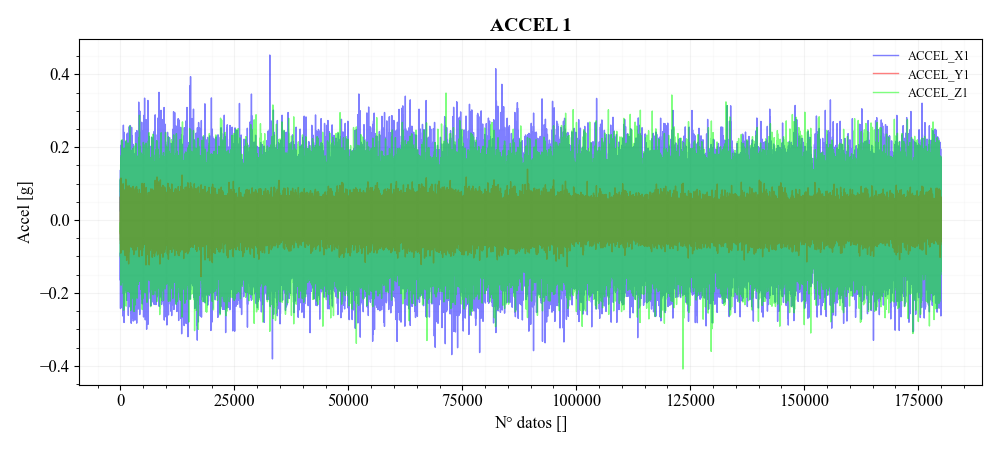

In [ ]:
plt.figure(figsize=(10, 4.5), dpi = 100)

plt.grid(which="major", alpha=0.15)
plt.minorticks_on()
plt.grid(which="minor", alpha=0.05)

plt.title('ACCEL 1', fontsize=14, fontweight='bold') 
plt.xlabel('N° datos []', fontsize=12)
plt.ylabel('Accel [g]', fontsize=12)

plt.plot(ndatos, X1, '-', alpha=0.5, linewidth=1, color='blue', label = 'ACCEL_X1')
plt.plot(ndatos, Y1, '-', alpha=0.5, linewidth=1, color='red', label = 'ACCEL_Y1')
plt.plot(ndatos, Z1, '-', alpha=0.5, linewidth=1, color='lime', label = 'ACCEL_Z1')

#plt.ylim(-1,1)

plt.legend(loc=1, fontsize=9, ncol=1, frameon=False)
plt.tight_layout()
#plt.savefig('Graf_FFT.jpg', dpi=800)
plt.show()

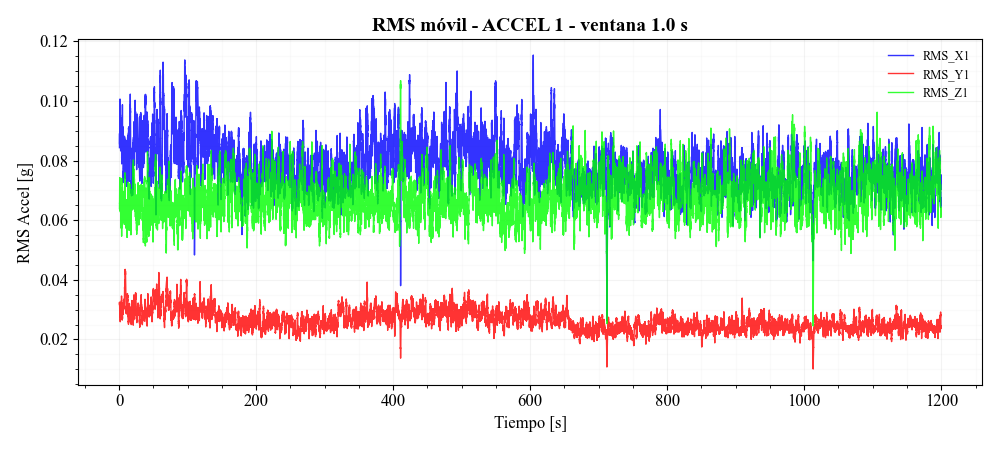

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Frecuencia de muestreo
fs = 150  # Hz

# Tiempo
t = df['t_s'].values

# Señales acelerómetro 1
X1 = df['X1L'].values
Y1 = df['Y1L'].values
Z1 = df['Z1L'].values

# Función RMS móvil
def rms_movil(signal, fs, ventana_s=1.0):
    n_ventana = int(ventana_s * fs)
    rms = (pd.Series(signal).rolling(window=n_ventana, center=True).apply(lambda x: np.sqrt(np.mean(x**2)), raw=True).values)

    return rms


# Calcular RMS móvil
ventana_s = 1.0  # segundos

X1_rms = rms_movil(X1, fs, ventana_s)
Y1_rms = rms_movil(Y1, fs, ventana_s)
Z1_rms = rms_movil(Z1, fs, ventana_s)

# Graficar RMS
plt.figure(figsize=(10, 4.5), dpi=100)

plt.grid(which="major", alpha=0.15)
plt.minorticks_on()
plt.grid(which="minor", alpha=0.05)

plt.title(f'RMS móvil - ACCEL 1 - ventana {ventana_s} s', fontsize=14, fontweight='bold')
plt.xlabel('Tiempo [s]', fontsize=12)
plt.ylabel('RMS Accel [g]', fontsize=12)

plt.plot(t, X1_rms, '-', alpha=0.8, linewidth=1, color='blue', label='RMS_X1')
plt.plot(t, Y1_rms, '-', alpha=0.8, linewidth=1, color='red', label='RMS_Y1')
plt.plot(t, Z1_rms, '-', alpha=0.8, linewidth=1, color='lime', label='RMS_Z1')

plt.legend(loc=1, fontsize=9, ncol=1, frameon=False)
plt.tight_layout()
plt.show()

In [ ]:
# quitar offset
X1 = signal.detrend(X1, type='constant')

In [ ]:
# -------------------------
# 4. Filtrado
# -------------------------
fc = 40.0
b, a = signal.butter(4, fc/(fs/2), btype='low') #Frecuencia de Nyquist fs/2

X1_f   = signal.filtfilt(b, a, X1)

In [ ]:

# 5. PSD
# PSD cuánta energía tiene la señal en cada frecuencia

nseg = 16384 #resolución espectral (grande)
f, Syy = welch(X1_f,  fs=fs, nperseg=nseg) #Esto calcula la densidad espectral de potencia de la señal salida

Frecuencias candidatas [Hz]:
[ 0.73242188  0.80566406  0.94299316  1.10778809  1.72119141  1.92260742
  2.19726562  2.50854492  2.70996094  2.92053223  2.97546387  3.14025879
  3.32336426  3.56140137  3.88183594  4.00085449  4.06494141  4.33959961
  4.4128418   4.89807129  4.97131348  5.24597168  5.45654297  5.49316406
  6.06079102  6.31713867  6.51855469  6.76574707  6.92138672  6.97631836
  7.3425293   7.67211914  8.36791992  8.50524902  8.60595703  8.99963379
  9.04541016  9.2010498   9.62219238  9.70458984  9.89685059 10.28137207
 10.78491211 10.8215332  10.84899902 11.05957031 11.16027832 11.28845215
 11.59973145 11.65466309 11.81030273 12.18566895 12.25891113 12.52441406
 12.74414062 12.90893555 13.2019043  13.4765625  13.68713379 13.83361816
 13.9251709  14.01672363 14.39208984 14.53857422 14.86816406 15.08789062
 15.18859863 15.30761719 15.69213867 15.81115723 16.0949707  16.28723145
 16.46118164 16.61682129 16.77246094 16.90979004 16.98303223 17.27600098
 17.49572754 17.852783

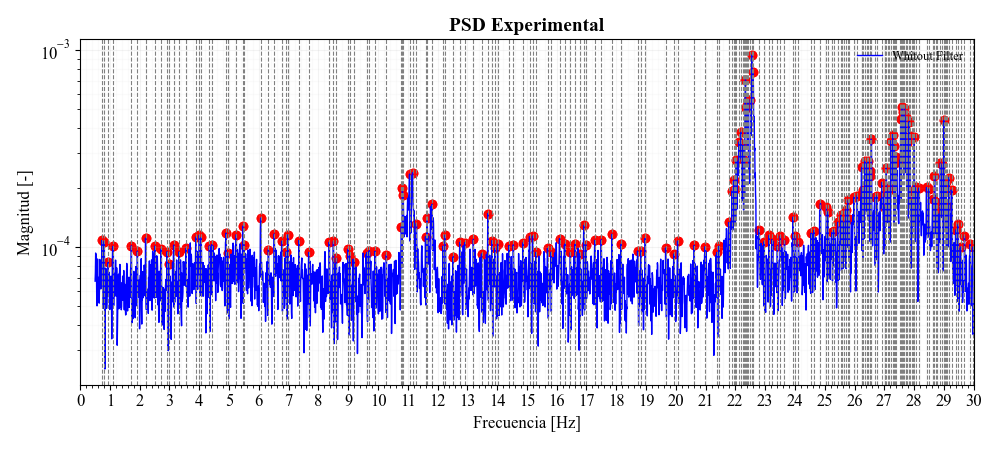

In [ ]:
# -------------------------
# 6. Buscar picos
# -------------------------
mask = (f >= 0.5) & (f <= 30)

peaks, props = find_peaks(np.abs(Syy[mask]), prominence=np.max(np.abs(Syy[mask]))*0.05)
freq_peaks = f[mask][peaks]

print("Frecuencias candidatas [Hz]:")
print(freq_peaks)

# -------------------------
# 7. Gráficos
# -------------------------
plt.figure(figsize=(10, 4.5), dpi = 100)

plt.grid(which="major", alpha=0.15)
plt.minorticks_on()
plt.grid(which="minor", alpha=0.05)

plt.title('PSD Experimental', fontsize=14, fontweight='bold') 
plt.xlabel('Frecuencia [Hz]', fontsize=12)
plt.ylabel('Magnitud [-]', fontsize=12)

plt.plot(f[mask], np.abs(Syy[mask]), '-', alpha=1, linewidth=1, color='blue', label = 'Whitout Filter')
plt.scatter(freq_peaks, np.abs(Syy[mask])[peaks], color='r')

plt.scatter(freq_peaks, np.abs(Syy[mask])[peaks], color='r')

for i in range(0, len(freq_peaks)):
    plt.axvline(freq_peaks[i], color='gray', linestyle='--', linewidth=0.8)

#plt.margins(y=0.1)

plt.xlim(0,30)
major_ticks_top=np.linspace(0,30,31)
plt.xticks(major_ticks_top)
plt.yscale('log')
plt.legend(loc=1, fontsize=9, ncol=1, frameon=False)
plt.tight_layout()
#plt.savefig('Graf_FFT.jpg', dpi=800)
plt.show()

In [ ]:
1/5

0.2

In [ ]:
x = np.array(df[list(df)[0]])
y1 = np.array(df[list(df)[1]])
y2 = np.array(df[list(df)[2]])
y3 = np.array(df[list(df)[3]])
y4 = np.array(df[list(df)[4]])

In [ ]:
#Filtrar Datos
F = 2048
fcut = 20; #frecuencia de corte para el filtro pasa baja
b, a = signal.butter(10, fcut/(F/2), 'low')

y1_filt = np.array(signal.filtfilt(b,a,df[list(df)[1]]))
y2_filt = np.array(signal.filtfilt(b,a,df[list(df)[2]]))
y3_filt = np.array(signal.filtfilt(b,a,df[list(df)[3]]))
y4_filt = np.array(signal.filtfilt(b,a,df[list(df)[4]]))

TypeError: unsupported operand type(s) for -: 'str' and 'str'

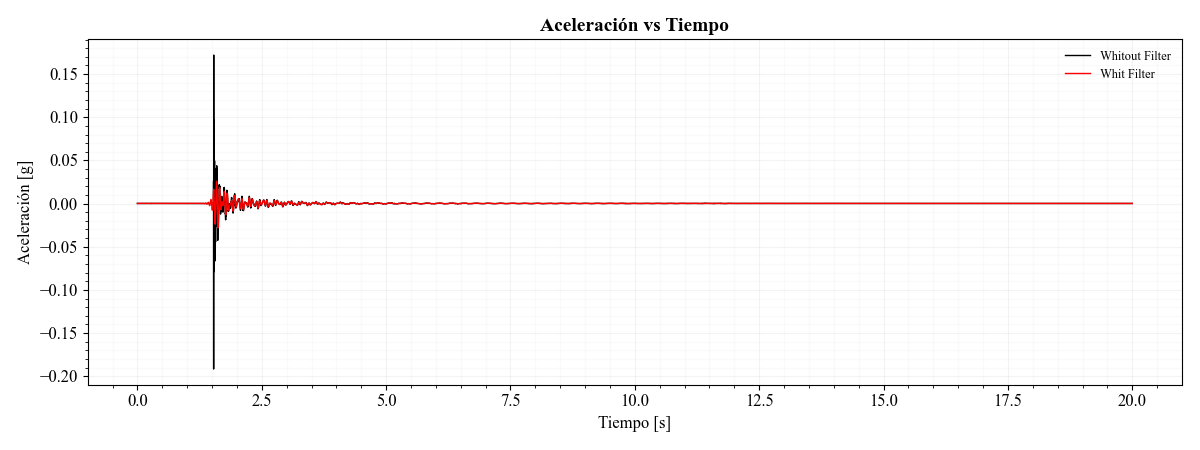

In [ ]:
plt.figure(figsize=(12, 4.5), dpi = 100)

plt.grid(which="major", alpha=0.15)
plt.minorticks_on()
plt.grid(which="minor", alpha=0.05)

plt.title('Aceleración vs Tiempo', fontsize=14, fontweight='bold') 
plt.xlabel('Tiempo [s]', fontsize=12)
plt.ylabel('Aceleración [g]', fontsize=12)

plt.plot(x, y1, alpha=1, linewidth=1, color='k', label = 'Whitout Filter')
plt.plot(x, y1_filt, alpha=1, linewidth=1, color='red', label = 'Whit Filter')

#plt.margins(y=0.1)

#plt.ylim(0,130000)
# major_ticks_top=np.linspace(0,2.5,6)
# plt.yticks(major_ticks_top)
    
plt.legend(loc=1, fontsize=9, ncol=1, frameon=False)
plt.tight_layout()
#plt.savefig('Graf_Accel.jpg', dpi=800)
plt.show()

In [ ]:
# Transformada Rapida de Fourier (FFT)

f = 2048
T = 1.0 / f
N = len(x)

x_f = np.linspace(0.0, 1.0/(2.0*T), N//2)  
x_ff = x_f[1:int(max(x_f))]

#Crear vectores 
y1_FFT = np.abs(scipy.fft.fft(y1))[1:int(max(x_f))]
y1_filt_FFT = np.abs(scipy.fft.fft(y1_filt))[1:int(max(x_f))]

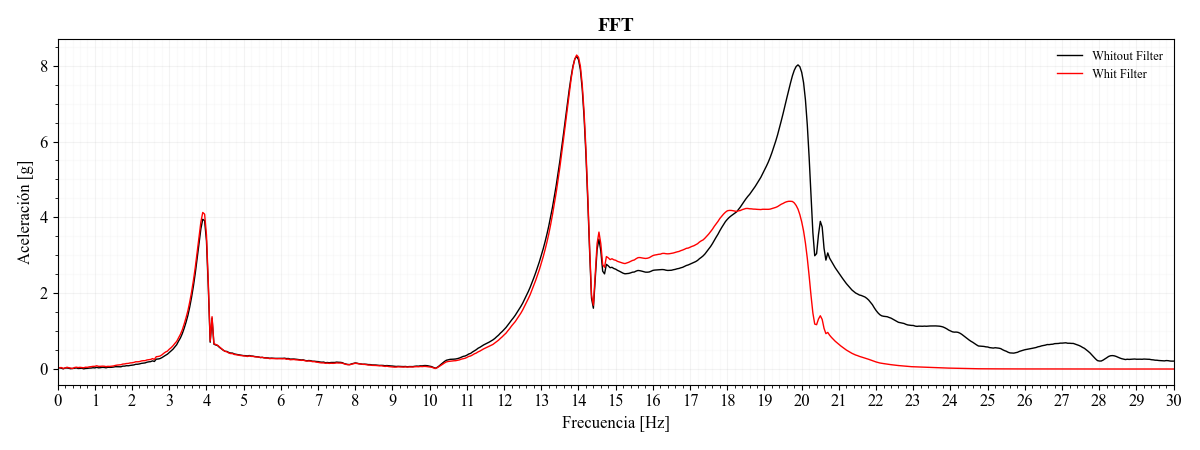

In [ ]:
plt.figure(figsize=(12, 4.5), dpi = 100)

plt.grid(which="major", alpha=0.15)
plt.minorticks_on()
plt.grid(which="minor", alpha=0.05)

plt.title('FFT', fontsize=14, fontweight='bold') 
plt.xlabel('Frecuencia [Hz]', fontsize=12)
plt.ylabel('Aceleración [g]', fontsize=12)

plt.plot(x_ff, y1_FFT, '-', alpha=1, linewidth=1, color='k', label = 'Whitout Filter')
plt.plot(x_ff, y1_filt_FFT, '-', alpha=1, linewidth=1, color='red', label = 'Whit Filter')

#plt.margins(y=0.1)

plt.xlim(0,30)
major_ticks_top=np.linspace(0,30,31)
plt.xticks(major_ticks_top)
    
plt.legend(loc=1, fontsize=9, ncol=1, frameon=False)
plt.tight_layout()
#plt.savefig('Graf_FFT.jpg', dpi=800)
plt.show()

In [ ]:
mask = (x_ff >= 0) & (x_ff <= 5)

y_rango = y1_FFT[mask]
x_rango = x_ff[mask]
idx_local = np.argmax(y_rango) # índice del máximo en el tramo analizado
f_pico = x_rango[idx_local]; y_pico = y_rango[idx_local]

print(f"Frecuencia Fundamental:\t{f_pico:.4f} [Hz]:")
print(f"Periodo Fundamental:\t{1/f_pico:.4f} [s]:")

Frecuencia Fundamental:	3.9002 [Hz]:
Periodo Fundamental:	0.2564 [s]:


In [ ]:
mask = (x_ff >= 13) & (x_ff <= 14)

y_rango = y1_FFT[mask]
x_rango = x_ff[mask]
idx_local = np.argmax(y_rango) # índice del máximo en el tramo analizado
f_pico = x_rango[idx_local]; y_pico = y_rango[idx_local]

print(f"Frecuencia Fundamental:\t{f_pico:.4f} [Hz]:")
print(f"Periodo Fundamental:\t{1/f_pico:.4f} [s]:")

Frecuencia Fundamental:	13.9507 [Hz]:
Periodo Fundamental:	0.0717 [s]:


In [ ]:
# + Masa ---> + Flexible ----> - Frecuencia
# + Rigidez ---> + Rigido ----> + Frecuencia



In [ ]:
import pandas as pd
import numpy as np

df = pd.read_table('./Registros/{}'.format(enss), skiprows=22, decimal=",")
df.columns = ['Tiempo [s]', 'S1', 'S2', 'S3', 'Hammer', 'Comment']
df.drop(['Comment'], axis=1, inplace=True)
display(df)

,Tiempo [s],S1,S2,S3,Hammer
0,0.000000,0.000179,0.000238,0.000227,0.000167
1,0.000488,0.000189,0.000314,0.000241,0.000106
2,0.000977,0.000146,0.000283,0.000228,0.000171
3,0.001465,0.000131,0.000301,0.000255,0.000177
4,0.001953,0.000176,0.000285,0.000218,0.000162
...,...,...,...,...,...
40955,19.997559,0.000154,0.000279,0.000255,0.000154
40956,19.998047,0.000138,0.000253,0.000236,0.000158
40957,19.998535,0.000157,0.000287,0.000252,0.000139
40958,19.999023,0.000172,0.000255,0.000243,0.000227


In [ ]:
#Crear los vectores
t = df['Tiempo [s]'].values
s1 = df['S1'].values
s2 = df['S2'].values
s3 = df['S3'].values

In [ ]:
#Calcular frecuencia de muestreo
dt = np.mean(np.diff(t))
fs = 1/dt
print(fs)

2047.9999711992973


In [ ]:
#Remover offset (MUY importante)
s1 = s1 - np.mean(s1)
s2 = s2 - np.mean(s2)
s3 = s3 - np.mean(s3)

In [ ]:
#Filtrado
from scipy import signal

fc = 20
b,a = signal.butter(4, fc/(fs/2), 'low')

s1_f = signal.filtfilt(b,a,s1)
s2_f = signal.filtfilt(b,a,s2)
s3_f = signal.filtfilt(b,a,s3)

In [ ]:
#FFT correcta
from scipy.fft import rfft, rfftfreq

N = len(t)

freq = rfftfreq(N, d=dt)

S1 = np.abs(rfft(s1))
S1f = np.abs(rfft(s1_f))

S2 = np.abs(rfft(s2))
S3 = np.abs(rfft(s3))

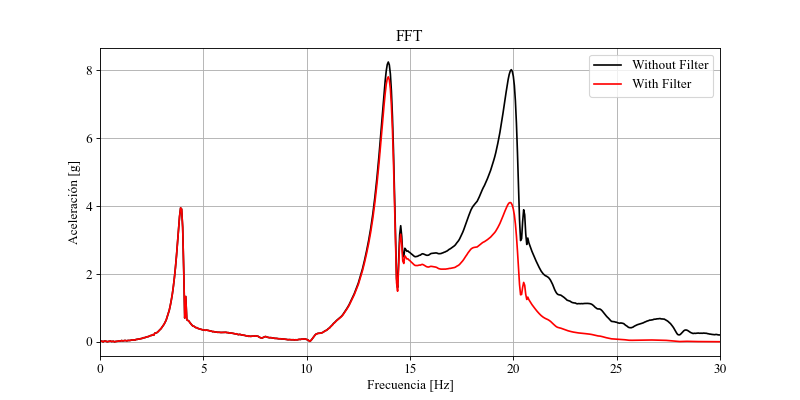

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(freq,S1,label='Without Filter',color='black')
plt.plot(freq,S1f,label='With Filter',color='red')

plt.xlim(0,30)

plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Aceleración [g]')
plt.title('FFT')

plt.legend()
plt.grid()

plt.show()

In [ ]:
from scipy.signal import find_peaks
peaks,_ = find_peaks(S1f,height=5)
freq_peaks = freq[peaks]
print(freq_peaks)

[13.9499998]


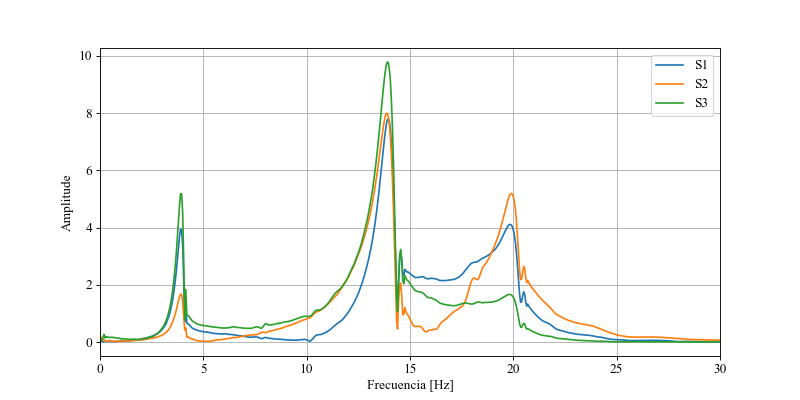

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(freq,np.abs(rfft(s1_f)),label='S1')
plt.plot(freq,np.abs(rfft(s2_f)),label='S2')
plt.plot(freq,np.abs(rfft(s3_f)),label='S3')

plt.xlim(0,30)

plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Amplitude')

plt.legend()
plt.grid()

plt.show()

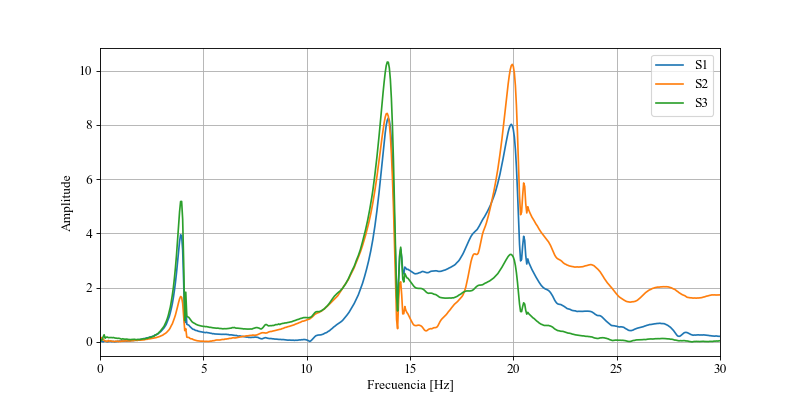

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(freq,S1,label='S1')
plt.plot(freq,S2,label='S2')
plt.plot(freq,S3,label='S3')

plt.xlim(0,30)

plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Amplitude')

plt.legend()
plt.grid()

plt.show()

In [ ]:
mask = (freq >= 0) & (freq <= 5)

y_rango = np.abs(rfft(s1_f))[mask]
x_rango = freq[mask]
idx_local = np.argmax(y_rango) # índice del máximo en el tramo analizado
f_pico = x_rango[idx_local]; y_pico = y_rango[idx_local]

print(f"Frecuencia Fundamental:\t{f_pico:.4f} [Hz]:")
print(f"Periodo Fundamental:\t{1/f_pico:.4f} [s]:")

Frecuencia Fundamental:	3.9000 [Hz]:
Periodo Fundamental:	0.2564 [s]:
